# My territory demo — you propose the doors, the system plans the route

This notebook makes the **caller-owned candidate list** explicit:

1. **Generate** fresh simulator logs + train a reward model (small, fast sandbox).
2. **You choose** today's territory: pick a center point and how many candidate doors to consider.
3. **The router** prices each door (`door_profit`) and runs TSP-with-Profits → visit order + dropped.
4. **At each stop** the bandit **recommends** an action (`recommend`) and you log **feedback**.

> Routing decides *where* to walk. The bandit decides *what to do* at each door. You supply the pool.


In [1]:
import tempfile
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nba.api.store import EventStore
from nba.bandits.epsilon_greedy import EpsilonGreedy
from nba.config import Settings
from nba.data import relational_simulator as rel
from nba.data.simulator import generate_logs
from nba.ethics import EthicalPolicy
from nba.eval.oracle import oracle_for
from nba.pipeline.orchestrator import Orchestrator
from nba.reward.model import RewardModel
from nba.routing.distance import HaversineEngine
from nba.schema import REWARD

warnings.filterwarnings("ignore", message="X does not have valid feature names")

SEED = 7
RNG = np.random.default_rng(SEED)
DATASET_MODE = "relational"  # "flat" | "relational"

# --- knobs you control as the territory manager ---
N_LOGS = 8_000          # training data size (keep modest for notebook speed)
MY_CENTER = (42.031, -93.618)  # lat/lon — your shift starting area
N_CANDIDATES = 60       # doors YOU propose for today's route pool
WALK_FIRST = 8          # how many stops to simulate door-by-door
REPLAN_EVERY = 4

tmp = Path(tempfile.mkdtemp(prefix="nba_territory_"))
settings = Settings(
    data_dir=tmp / "data",
    model_dir=tmp / "models",
    db_path=tmp / "events.db",
    dataset_mode=DATASET_MODE,
    seed=SEED,
)
settings.ensure_dirs()
print(f"sandbox: {tmp}")


sandbox: /tmp/nba_territory_frdvv9a1


## 1. Generate fresh logs and train the reward model

The simulator creates labeled `(context, action, reward, propensity)` rows. We fit `q(x,a)` on them.
This is the **offline learning** phase — it happens before you propose today's door list.


In [2]:
if settings.dataset_mode == "relational":
    events, world = rel.generate_logs(N_LOGS, settings=settings, seed=SEED)
else:
    events = generate_logs(N_LOGS, settings=settings, seed=SEED)
    world = None

model = RewardModel.fit(events, settings=settings)
model.save(settings.model_dir)
print(f"trained on {len(events):,} events → {settings.model_dir}")


trained on 8,000 events → /tmp/nba_territory_frdvv9a1/models


## 2. You propose today's candidate doors

**This is your job as territory manager.** The orchestrator never discovers doors on its own — you pass
a list of `ProspectContext`. Here we sample fresh doors from the simulator, then **you** pin them near
`MY_CENTER` so the cluster is walkable (same trick as `run_demo._dense_block`).

Change `MY_CENTER`, `N_CANDIDATES`, or pick specific `address_id`s from the table below.


In [3]:
from nba.data.simulator import sample_context
from nba.data.ames import load_ames

ames = load_ames(settings, seed=SEED)
rows = ames.sample(n=N_CANDIDATES * 3, replace=True, random_state=SEED).reset_index(drop=True)
raw = [sample_context(rows.iloc[i].to_dict(), RNG) for i in range(len(rows))]

# Place on a disk around YOUR center (sqrt-uniform radius → uniform over area)
lat_km = 1.0 / 111.2
lon_km = 1.0 / (111.2 * np.cos(np.radians(MY_CENTER[0])))
radius_km = 0.25
placed = []
for ctx in raw:
    r = radius_km * np.sqrt(RNG.random())
    theta = RNG.uniform(0, 2 * np.pi)
    lat = MY_CENTER[0] + r * np.sin(theta) * lat_km
    lon = MY_CENTER[1] + r * np.cos(theta) * lon_km
    placed.append(ctx.model_copy(update={"lat": lat, "lon": lon}))

# YOU pick the candidate list (here: first N_CANDIDATES after shuffle)
RNG.shuffle(placed)
my_doors = placed[:N_CANDIDATES]

preview = pd.DataFrame(
    {
        "address_id": [c.address_id[:8] + "…" for c in my_doors[:8]],
        "lat": [round(c.lat, 5) for c in my_doors[:8]],
        "lon": [round(c.lon, 5) for c in my_doors[:8]],
        "property_value": [int(c.property_value) for c in my_doors[:8]],
    }
)
print(f"YOU proposed {len(my_doors)} candidate doors near {MY_CENTER}")
print(preview.to_string(index=False))


YOU proposed 60 candidate doors near (42.031, -93.618)
address_id      lat       lon  property_value
 00000000… 42.03096 -93.61508          174313
 00000000… 42.02968 -93.61897          202584
 00000000… 42.03002 -93.61887          209251
 00000000… 42.03041 -93.61989          215106
 00000000… 42.03231 -93.62017          125813
 00000000… 42.03105 -93.61722          180454
 00000000… 42.03251 -93.61726          268722
 00000000… 42.03010 -93.61804          190177


## 3. Router: plan the day's walk (TSP-with-Profits)

`plan_route(my_doors)` prices each door with bandit-weighted profit and asks OR-Tools which subset/order
maximizes value minus walking time, subject to `shift_capacity` and the residential time window.


In [4]:
policy = EthicalPolicy(
    EpsilonGreedy(model, epsilon=settings.epsilon, rng=RNG),
    settings,
    rng=RNG,
)
store = EventStore(settings.db_path)
orch = Orchestrator(
    policy=policy,
    reward_model=model,
    distance_engine=HaversineEngine(speed_kmh=settings.walking_speed_kmh),
    store=store,
    settings=settings,
)

if settings.dataset_mode == "relational":
    from nba.data.relational_simulator import world_from_contexts
    eval_world = world_from_contexts(my_doors, settings=settings, seed=SEED + 1)
else:
    eval_world = None
oracle = oracle_for(settings, world=eval_world)

profits = [orch.door_profit(c) for c in my_doors]
route = orch.plan_route(my_doors)
print(f"candidate doors : {len(my_doors)}")
print(f"  visited       : {len(route.visited)}  (capacity={settings.shift_capacity})")
print(f"  dropped       : {len(route.dropped)}")
print(f"  walk+dwell    : {route.total_time_s / 60:.1f} min")
print(f"  route profit  : {route.total_profit:.2f}")
print(f"  door_profit   : min={min(profits):.3f}  mean={np.mean(profits):.3f}  max={max(profits):.3f}")


candidate doors : 60
  visited       : 40  (capacity=40)
  dropped       : 20
  walk+dwell    : 106.3 min
  route profit  : 6.12
  door_profit   : min=0.004  mean=0.135  max=0.309


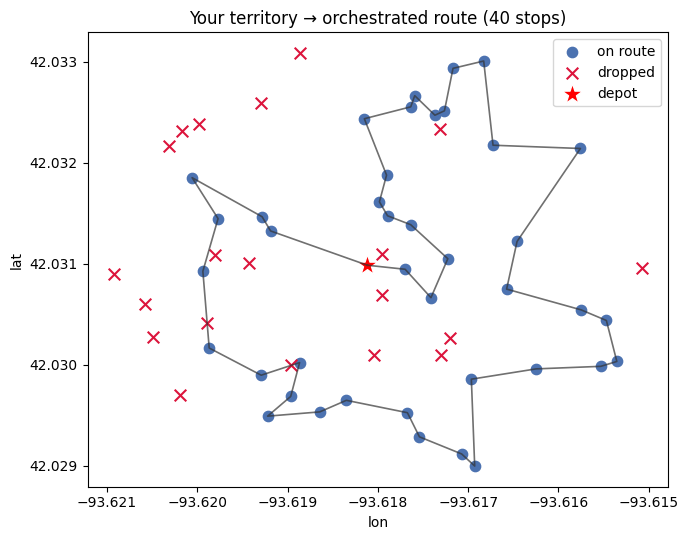

In [5]:
# Map: visited vs dropped (solver node 0 = depot, 1..n = doors)
door_coords = np.array([(c.lat, c.lon) for c in my_doors])
depot = door_coords.mean(axis=0)
coords = np.vstack([depot, door_coords])  # index 0 = depot, 1..n = doors

fig, ax = plt.subplots(figsize=(7, 5.5))
vis = np.array(route.visited, dtype=int) if route.visited else np.array([], dtype=int)
if vis.size:
    ax.scatter(coords[vis, 1], coords[vis, 0], c="#4C72B0", s=55, label="on route")
if route.dropped:
    dr = np.array(route.dropped, dtype=int)
    ax.scatter(coords[dr, 1], coords[dr, 0], marker="x", c="crimson", s=70, label="dropped")
path = coords[route.order]
ax.plot(path[:, 1], path[:, 0], "-", color="#333", lw=1.2, alpha=0.7)
ax.scatter(depot[1], depot[0], marker="*", c="red", s=250, edgecolor="white", label="depot")
ax.set(title=f"Your territory → orchestrated route ({len(route.visited)} stops)", xlabel="lon", ylabel="lat")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Walk the route: recommend door-by-door

For each stop on the route, the bandit picks an **action** and logs **propensity**. Outcomes append to
the event store for future retraining.


In [6]:
remaining = list(my_doors)
order = [remaining[i - 1] for i in route.order if i != 0]
rows = []
step = 0
while order and step < WALK_FIRST:
    door = order.pop(0)
    rec = orch.recommend(door)
    outcome = oracle.sample_outcome(door, rec.action, RNG)
    orch.feedback(rec.decision_id, outcome)
    rows.append(
        {
            "stop": step + 1,
            "action": rec.action.value,
            "propensity": round(rec.propensity, 3),
            "outcome": outcome.value,
            "reward": REWARD[outcome],
            "q_best": round(max(rec.q_values.values()), 3),
        }
    )
    remaining.remove(door)
    step += 1
    if step % REPLAN_EVERY == 0 and remaining and order:
        route = orch.replan(remaining)
        order = [remaining[i - 1] for i in route.order if i != 0]
        print(f"  replanned after stop {step}: {len(route.visited)} remaining stops")

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nlogged decisions: {orch.decision_count()}")


  replanned after stop 4: 40 remaining stops


  replanned after stop 8: 40 remaining stops
 stop         action  propensity     outcome  reward  q_best
    1    pitch_solar       0.920 appointment     0.3   0.192
    2      skip_door       0.020    not_home     0.0   0.144
    3      knock_now       0.245    not_home     0.0   0.144
    4    pitch_solar       0.920  info_given     0.1   0.135
    5 pitch_security       0.245      closed     1.0   0.144
    6    pitch_solar       0.470     slammed    -0.2   0.135
    7    pitch_solar       0.920 appointment     0.3   0.325
    8    leave_flyer       0.245 appointment     0.3   0.144

logged decisions: 8
